<a href="https://colab.research.google.com/github/marthahuertas-lgtm/Relatorio/blob/main/Trabalho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Trabajo Topicos**

**1. Parte exploratoria**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [2]:
#PARTE 2: EXPLORACIÓN INICIAL DEL DATASET
# Cargar datos
dados= pd.read_csv('cardio_train.csv', sep=';')
display(dados.head())

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [4]:
len(dados)

70000

In [5]:
len(dados.columns)

13

In [6]:
#verificando valores faltantes
dados.isnull().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


Eliminamos la variable Id

In [7]:
dados = dados.drop(['id'], axis = 1)
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  int64  
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.4 MB


Calculando las estadisticas descriptivas

In [8]:

display(dados.describe())

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


Calculamos la correlación

In [9]:
dados.corr(numeric_only=True)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
age,1.000000,-0.022811,-0.081515,0.053684,0.020764,0.017647,0.154424,0.098703,-0.047633,-0.029723,-0.009927,0.238159
gender,-0.022811,1.000000,0.499033,0.155406,0.006005,0.015254,-0.035821,-0.020491,0.338135,0.170966,0.005866,0.008109
height,-0.081515,0.499033,1.000000,0.290968,0.005488,0.006150,-0.050226,-0.018595,0.187989,0.094419,-0.006570,-0.010821
weight,0.053684,0.155406,0.290968,1.000000,0.030702,0.043710,0.141768,0.106857,0.067780,0.067113,-0.016867,0.181660
ap_hi,0.020764,0.006005,0.005488,0.030702,1.000000,0.016086,0.023778,0.011841,-0.000922,0.001408,-0.000033,0.054475
ap_lo,0.017647,0.015254,0.006150,0.043710,0.016086,1.000000,0.024019,0.010806,0.005186,0.010601,0.004780,0.065719
cholesterol,0.154424,-0.035821,-0.050226,0.141768,0.023778,0.024019,1.000000,0.451578,0.010354,0.035760,0.009911,0.221147
gluc,0.098703,-0.020491,-0.018595,0.106857,0.011841,0.010806,0.451578,1.000000,-0.004756,0.011246,-0.006770,0.089307
smoke,-0.047633,0.338135,0.187989,0.067780,-0.000922,0.005186,0.010354,-0.004756,1.000000,0.340094,0.025858,-0.015486
alco,-0.029723,0.170966,0.094419,0.067113,0.001408,0.010601,0.035760,0.011246,0.340094,1.000000,0.025476,-0.007330


* creación de dos variables IBM (peso de masa corporal con las variables peso y altura) y Age_years ya que la edad esta calculada en días.
* Codificación variable genero: 0= mujer y 1 = hombre

In [10]:
dados['age_years'] = dados['age'] / 365.25
dados['bmi'] = dados['weight'] / (dados['height']/100) ** 2

dados = dados[(dados['ap_hi'] >= 80) & (dados['ap_hi'] <= 250)]
dados = dados[(dados['ap_lo'] >= 40) & (dados['ap_lo'] <= 150)]
dados= dados[dados['ap_hi'] > dados['ap_lo']]

dados = dados[(dados['bmi'] >= 15) & (dados['bmi'] <= 50)]

dados['gender'] = dados['gender'] - 1

**Analisis univariado**

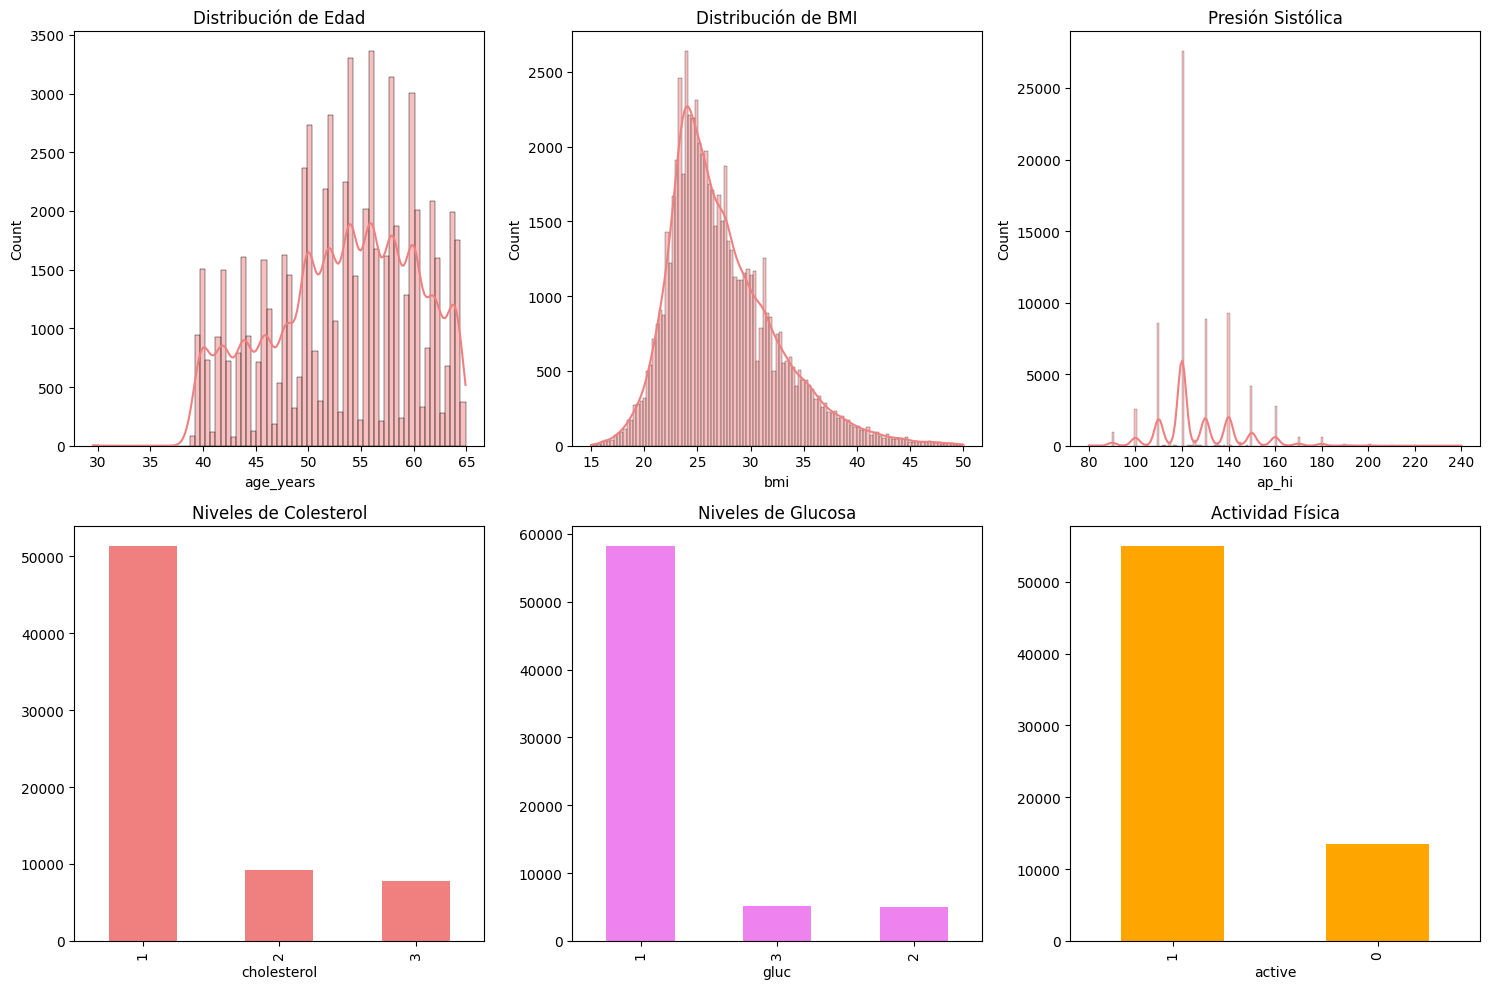

In [11]:
#ANÁLISIS UNIVARIADO
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sns.histplot(data=dados, x='age_years', kde=True, ax=axes[0,0], color='lightcoral')
axes[0,0].set_title('Distribución de Edad')

sns.histplot(data=dados, x='bmi', kde=True, ax=axes[0,1], color='lightcoral')
axes[0,1].set_title('Distribución de BMI')

sns.histplot(data=dados, x='ap_hi', kde=True, ax=axes[0,2], color='lightcoral')
axes[0,2].set_title('Presión Sistólica')

dados['cholesterol'].value_counts().plot(kind='bar', ax=axes[1,0], color='lightcoral')
axes[1,0].set_title('Niveles de Colesterol')

dados['gluc'].value_counts().plot(kind='bar', ax=axes[1,1], color='violet')
axes[1,1].set_title('Niveles de Glucosa')

dados['active'].value_counts().plot(kind='bar', ax=axes[1,2], color='orange')
axes[1,2].set_title('Actividad Física')

plt.tight_layout()
plt.show()

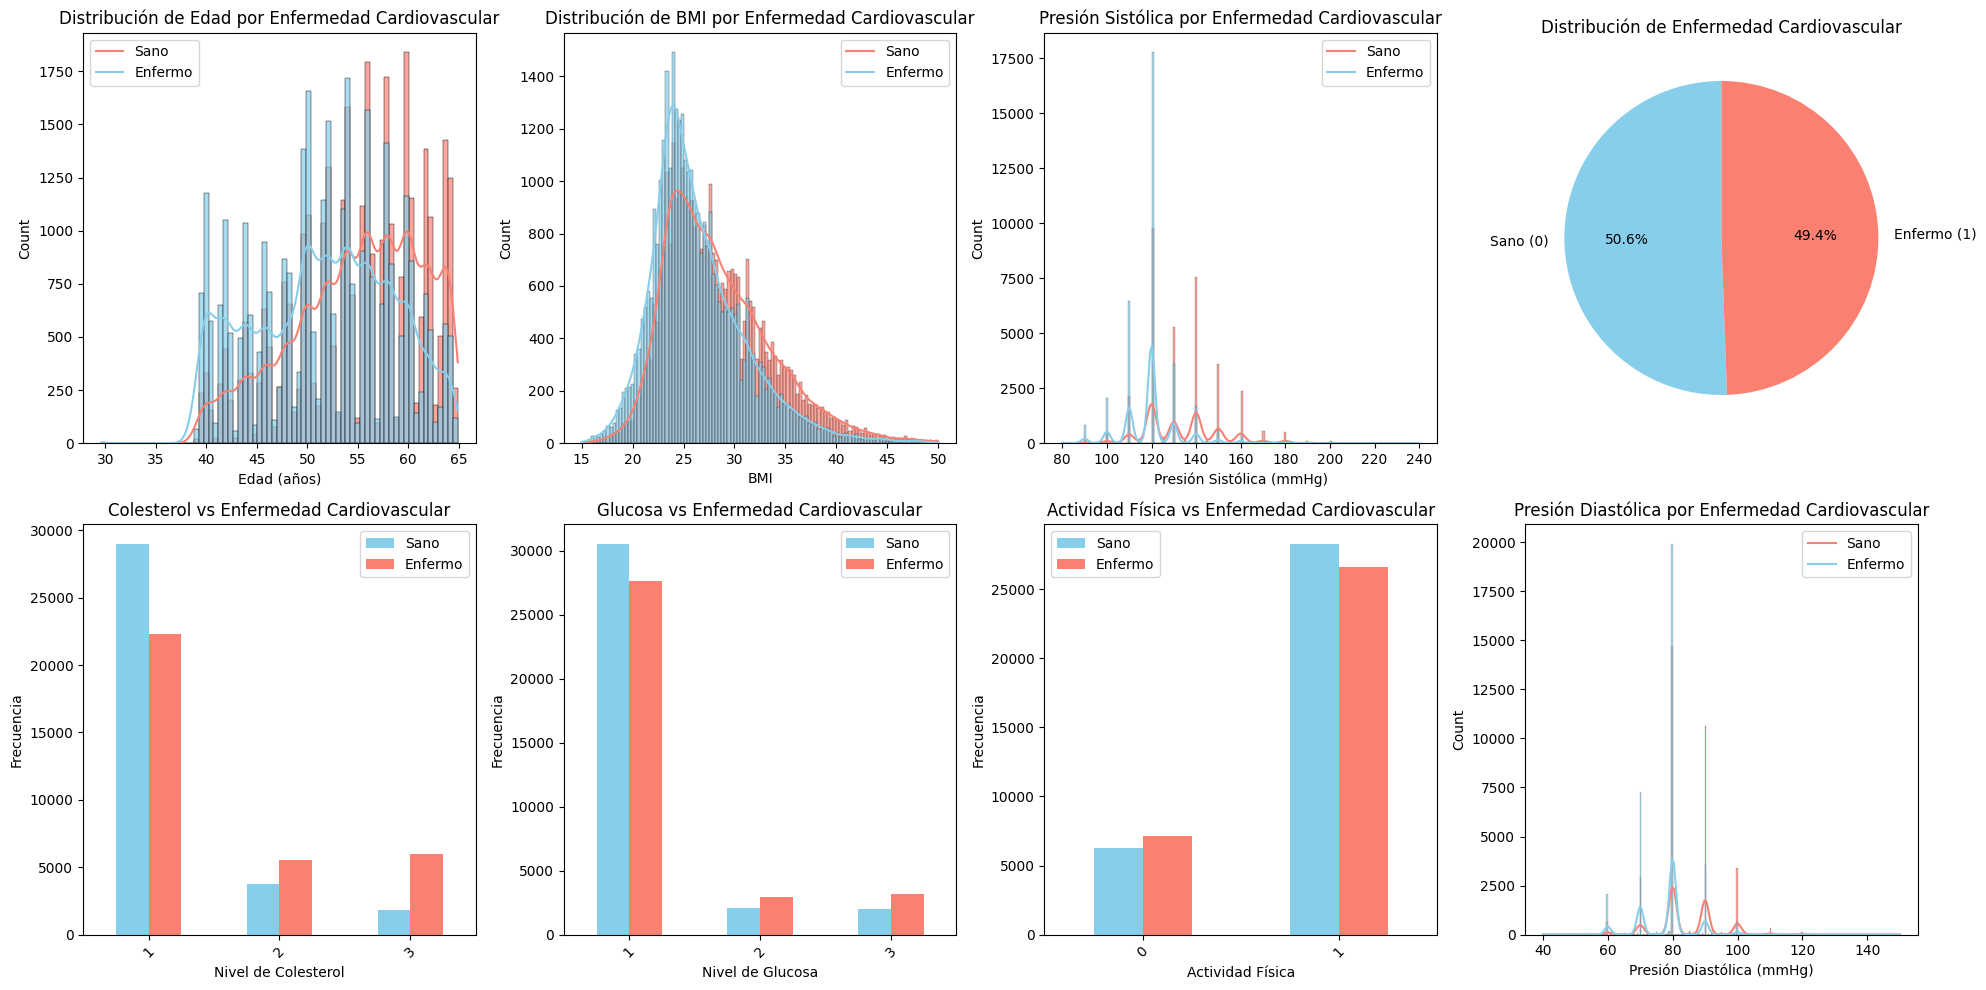

       RESUMEN ESTADÍSTICO POR CONDICIÓN CARDIOVASCULAR

PROPORCIÓN DE FACTORES DE RIESGO POR GRUPO:

CHOLESTEROL:
cardio           0      1
cholesterol              
1            83.83  66.04
2            10.80  16.31
3             5.37  17.64

GLUC:
cardio      0      1
gluc                
1       88.26  81.83
2        6.00   8.73
3        5.73   9.44

SMOKE:
cardio      0      1
smoke               
0       90.74  91.66
1        9.26   8.34

ALCO:
cardio      0      1
alco                
0       94.48  94.85
1        5.52   5.15

ACTIVE:
cardio      0      1
active              
0       18.18  21.18
1       81.82  78.82


In [14]:
# ANÁLISIS UNIVARIADO CON DISTRIBUCIÓN DE ENFERMEDAD CARDIOVASCULAR
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Gráfico 1: Distribución de Edad por condición cardiovascular
sns.histplot(data=dados, x='age_years', hue='cardio', kde=True, ax=axes[0,0],
             palette=['skyblue', 'salmon'], alpha=0.7)
axes[0,0].set_title('Distribución de Edad por Enfermedad Cardiovascular')
axes[0,0].set_xlabel('Edad (años)')
axes[0,0].legend(['Sano', 'Enfermo'])

# Gráfico 2: Distribución de BMI por condición cardiovascular
sns.histplot(data=dados, x='bmi', hue='cardio', kde=True, ax=axes[0,1],
             palette=['skyblue', 'salmon'], alpha=0.7)
axes[0,1].set_title('Distribución de BMI por Enfermedad Cardiovascular')
axes[0,1].set_xlabel('BMI')
axes[0,1].legend(['Sano', 'Enfermo'])

# Gráfico 3: Presión Sistólica por condición cardiovascular
sns.histplot(data=dados, x='ap_hi', hue='cardio', kde=True, ax=axes[0,2],
             palette=['skyblue', 'salmon'], alpha=0.7)
axes[0,2].set_title('Presión Sistólica por Enfermedad Cardiovascular')
axes[0,2].set_xlabel('Presión Sistólica (mmHg)')
axes[0,2].legend(['Sano', 'Enfermo'])

# Gráfico 4: DISTRIBUCIÓN DE LA ENFERMEDAD CARDIOVASCULAR
cardio_counts = dados['cardio'].value_counts()
colors = ['skyblue', 'salmon']
labels = ['Sano (0)', 'Enfermo (1)']
axes[0,3].pie(cardio_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0,3].set_title('Distribución de Enfermedad Cardiovascular')

# Gráfico 5: Colesterol por condición cardiovascular
pd.crosstab(dados['cholesterol'], dados['cardio']).plot(kind='bar', ax=axes[1,0],
                                                       color=['skyblue', 'salmon'])
axes[1,0].set_title('Colesterol vs Enfermedad Cardiovascular')
axes[1,0].set_xlabel('Nivel de Colesterol')
axes[1,0].set_ylabel('Frecuencia')
axes[1,0].legend(['Sano', 'Enfermo'])
axes[1,0].tick_params(axis='x', rotation=45)

# Gráfico 6: Glucosa por condición cardiovascular
pd.crosstab(dados['gluc'], dados['cardio']).plot(kind='bar', ax=axes[1,1],
                                                color=['skyblue', 'salmon'])
axes[1,1].set_title('Glucosa vs Enfermedad Cardiovascular')
axes[1,1].set_xlabel('Nivel de Glucosa')
axes[1,1].set_ylabel('Frecuencia')
axes[1,1].legend(['Sano', 'Enfermo'])
axes[1,1].tick_params(axis='x', rotation=45)

# Gráfico 7: Actividad Física por condición cardiovascular
pd.crosstab(dados['active'], dados['cardio']).plot(kind='bar', ax=axes[1,2],
                                                  color=['skyblue', 'salmon'])
axes[1,2].set_title('Actividad Física vs Enfermedad Cardiovascular')
axes[1,2].set_xlabel('Actividad Física')
axes[1,2].set_ylabel('Frecuencia')
axes[1,2].legend(['Sano', 'Enfermo'])
axes[1,2].tick_params(axis='x', rotation=45)

# Gráfico 8: Presión Diastólica por condición cardiovascular
sns.histplot(data=dados, x='ap_lo', hue='cardio', kde=True, ax=axes[1,3],
             palette=['skyblue', 'salmon'], alpha=0.7)
axes[1,3].set_title('Presión Diastólica por Enfermedad Cardiovascular')
axes[1,3].set_xlabel('Presión Diastólica (mmHg)')
axes[1,3].legend(['Sano', 'Enfermo'])

plt.tight_layout()
plt.show()

# ANÁLISIS BIVARIADO ADICIONAL - FACTORES DE RIESGO
print("       RESUMEN ESTADÍSTICO POR CONDICIÓN CARDIOVASCULAR")

# Proporciones de factores de riesgo
print("\nPROPORCIÓN DE FACTORES DE RIESGO POR GRUPO:")
risk_factors = ['cholesterol', 'gluc', 'smoke', 'alco', 'active']
for factor in risk_factors:
    prop_table = pd.crosstab(dados[factor], dados['cardio'], normalize='columns') * 100
    print(f"\n{factor.upper()}:")
    print(prop_table.round(2))

**Analisis bivariado**

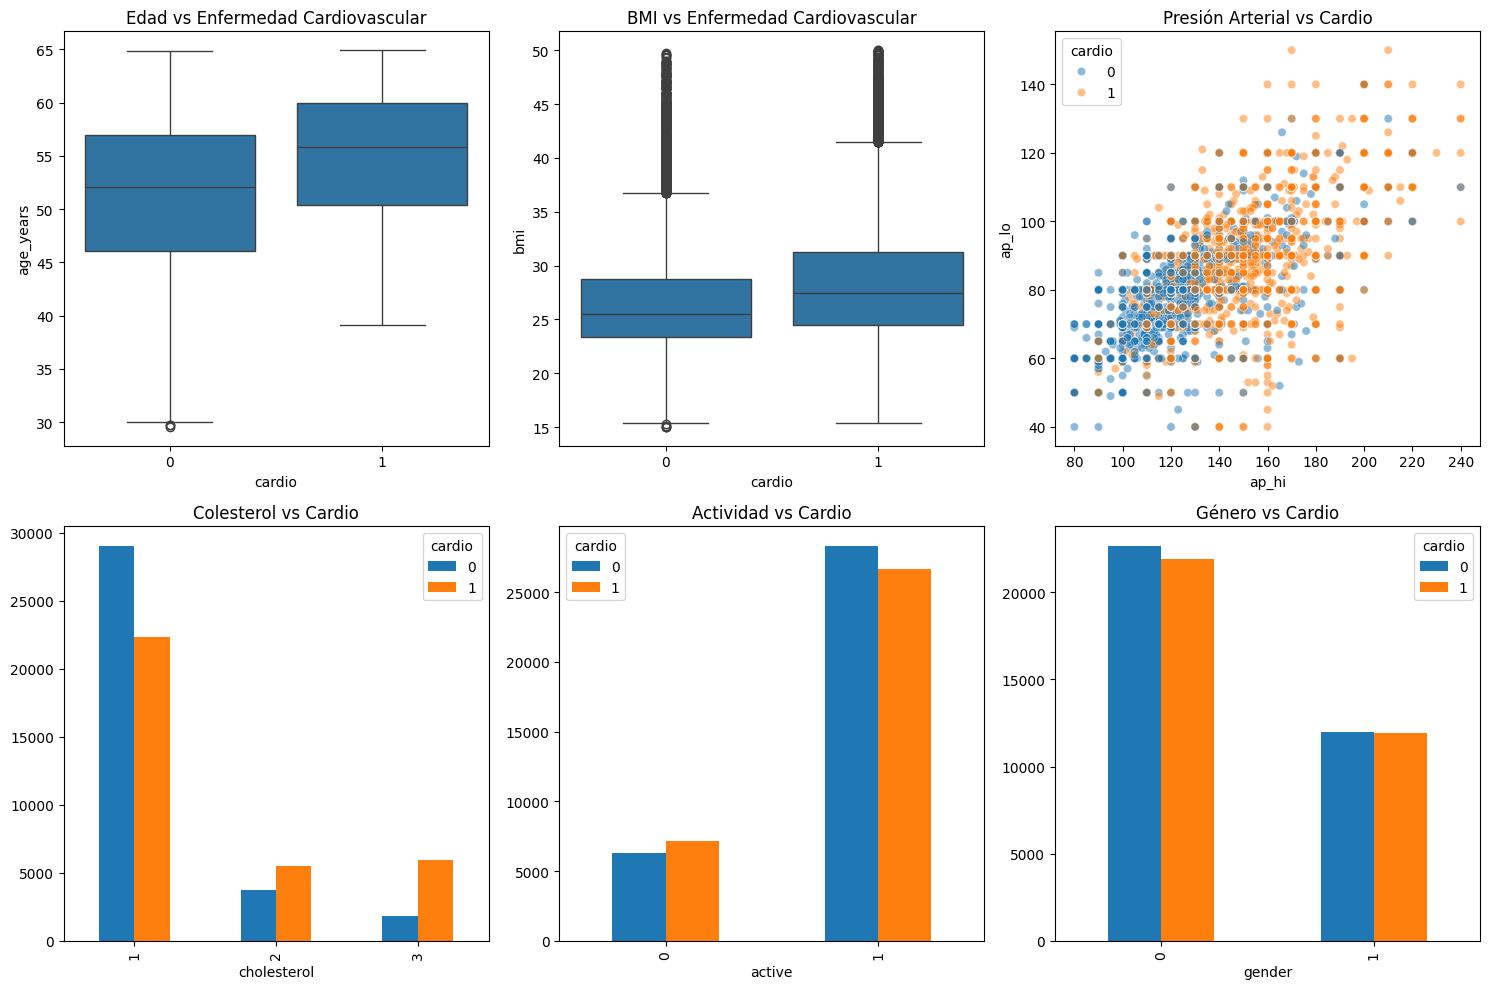

In [15]:
# PARTE 6: ANÁLISIS BIVARIADO
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sns.boxplot(data=dados, x='cardio', y='age_years', ax=axes[0,0])
axes[0,0].set_title('Edad vs Enfermedad Cardiovascular')

sns.boxplot(data=dados, x='cardio', y='bmi', ax=axes[0,1])
axes[0,1].set_title('BMI vs Enfermedad Cardiovascular')

sns.scatterplot(data=dados, x='ap_hi', y='ap_lo', hue='cardio', alpha=0.5, ax=axes[0,2])
axes[0,2].set_title('Presión Arterial vs Cardio')

pd.crosstab(dados['cholesterol'], dados['cardio']).plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Colesterol vs Cardio')

pd.crosstab(dados['active'], dados['cardio']).plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Actividad vs Cardio')

pd.crosstab(dados['gender'], dados['cardio']).plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Género vs Cardio')

plt.tight_layout()
plt.show()

**Matriz de correlación**

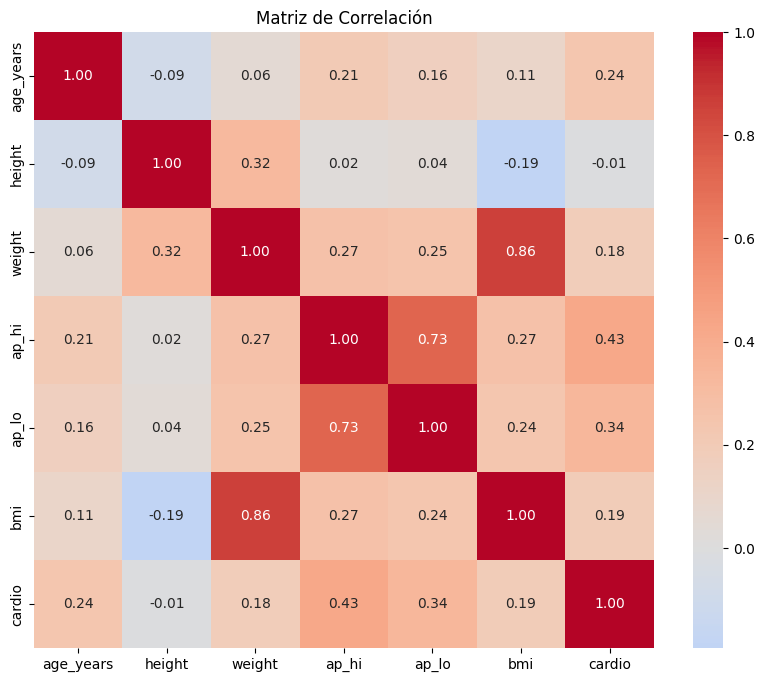

In [16]:
numeric_vars = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'cardio']
corr_data = dados[numeric_vars]
corr_matrix = corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

* Para guardar los datos preprocesados

In [17]:
dados.to_csv('cardio_dataset_procesado.csv', index=False)

# **Resumen del analisis exploratorio**

In [18]:
print("RESUMEN ESTADÍSTICO DEL ANÁLISIS EXPLORATORIO")


print("\n DISTRIBUCIÓN DE VARIABLES NUMÉRICAS:")
print(f" Edad: {dados['age_years'].mean():.1f} ± {dados['age_years'].std():.1f} años")
print(f" BMI: {dados['bmi'].mean():.1f} ± {dados['bmi'].std():.1f} kg/m²")
print(f" Presión Sistólica: {dados['ap_hi'].mean():.1f} ± {dados['ap_hi'].std():.1f} mmHg")
print(f" Presión Diastólica: {dados['ap_lo'].mean():.1f} ± {dados['ap_lo'].std():.1f} mmHg")

print("\n DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS:")
print(f" Enfermedad Cardiovascular: {dados['cardio'].mean():.1%}")
print(f" Colesterol Alto: {(dados['cholesterol'] > 1).mean():.1%}")
print(f" Glucosa Alta: {(dados['gluc'] > 1).mean():.1%}")
print(f" Personas Activas: {dados['active'].mean():.1%}")

print("\n CORRELACIONES PRINCIPALES:")
corr_matrix = dados[['age_years', 'ap_hi', 'ap_lo', 'bmi', 'cardio']].corr()
print(f" Edad vs Cardio: {corr_matrix.loc['age_years', 'cardio']:.3f}")
print(f" Presión Sistólica vs Cardio: {corr_matrix.loc['ap_hi', 'cardio']:.3f}")
print(f" BMI vs Cardio: {corr_matrix.loc['bmi', 'cardio']:.3f}")



RESUMEN ESTADÍSTICO DEL ANÁLISIS EXPLORATORIO

 DISTRIBUCIÓN DE VARIABLES NUMÉRICAS:
 Edad: 53.3 ± 6.8 años
 BMI: 27.4 ± 5.0 kg/m²
 Presión Sistólica: 126.6 ± 16.6 mmHg
 Presión Diastólica: 81.3 ± 9.4 mmHg

 DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS:
 Enfermedad Cardiovascular: 49.4%
 Colesterol Alto: 25.0%
 Glucosa Alta: 14.9%
 Personas Activas: 80.3%

 CORRELACIONES PRINCIPALES:
 Edad vs Cardio: 0.240
 Presión Sistólica vs Cardio: 0.428
 BMI vs Cardio: 0.193


**Objetivo :** Desarrollar y evaluar un modelo de Red Neuronal Multicapa (MLP) con técnicas de regularización con y sin Dropout para la predicción de enfermedad cardiovascular.

In [19]:

# IMPORTACIÓN DE LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Scikit-learn para preprocesamiento y métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix,
                             classification_report)

# TensorFlow/Keras para redes neuronales
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


Como los datos ya estan preprocesados y se realizaron creacion de nuevas variables trabajaremos con ellos

In [49]:
# DEFINIR FEATURES Y TARGET
features = ['gender', 'height', 'weight', 'ap_hi', 'ap_lo',
           'cholesterol', 'gluc', 'smoke', 'alco', 'active',
           'age_years', 'bmi']

X = dados[features]
y = dados['cardio']

# Para ubicar por categorias las variables categoricas
X = pd.get_dummies(X, columns=['cholesterol', 'gluc'], drop_first=True)

print(f"Dataset preparado para MLP:")
print(f"Features: {X.shape[1]} variables")


Dataset preparado para MLP:
Features: 14 variables


* Dividimos los datos

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar características y variable objetivo
X = dados.drop('cardio', axis=1)  # 'cardio' es la variable objetivo en este dataset
y = dados['cardio']

print(f"Dimensiones: {X.shape}")
print(f"Proporción de clases: {y.value_counts(normalize=True)}")

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

Dimensiones: (68401, 13)
Proporción de clases: cardio
0    0.505767
1    0.494233
Name: proportion, dtype: float64
Train: (47880, 13), Test: (20521, 13)


In [22]:
def create_mlp_con_dropout(input_dim):
    """
    MLP CON Dropout
    """
    model = Sequential([
        # Capa densa 1: 128 neuronas + Dropout 40%
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.4),  # 40% de neuronas apagadas en cada iteración

        # Capa densa 2: 64 neuronas + Dropout 30%
        Dense(64, activation='relu'),
        Dropout(0.3),  # 30% de neuronas apagadas

        # Capa densa 3: 32 neuronas + Dropout 20%
        Dense(32, activation='relu'),
        Dropout(0.2),  #20% de neuronas apagadas

        # Capa de salida: 1 neurona (clasificación binaria)
        Dense(1, activation='sigmoid')
    ])

    # Compilar modelo
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 'AUC']
    )
    return model

In [23]:
def create_mlp_sin_dropout(input_dim):
    """
    MLP SIN Dropout
    """
    model = Sequential([
        # Misma arquitectura pero SIN dropout
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    # Misma configuración de compilación para comparación justa
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 'AUC']
    )
    return model


* Entrenando los modelos

In [24]:
# MODELO 1: CON DROPOUT
modelo_con_dropout = Sequential([
    # Capa densa 1: 128 neuronas + Dropout 40%
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.4),  # 40% de neuronas apagadas en cada iteración

    # Capa densa 2: 64 neuronas + Dropout 30%
    Dense(64, activation='relu'),
    Dropout(0.3),  # 30% de neuronas apagadas

    # Capa densa 3: 32 neuronas + Dropout 20%
    Dense(32, activation='relu'),
    Dropout(0.2),  # 20% de neuronas apagadas

    # Capa de salida: 1 neurona (clasificación binaria)
    Dense(1, activation='sigmoid')
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
modelo_con_dropout.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

Trenando el modelo con dropout

In [26]:
history_con_dropout = modelo_con_dropout.fit(X_train_scaled, y_train, epochs=50, batch_size=128, validation_split=0.2,
    verbose=1
)

Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.7375 - accuracy: 0.6759 - loss: 0.6047 - val_AUC: 0.7860 - val_accuracy: 0.7245 - val_loss: 0.5614
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.7878 - accuracy: 0.7245 - loss: 0.5633 - val_AUC: 0.7876 - val_accuracy: 0.7253 - val_loss: 0.5578
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7901 - accuracy: 0.7269 - loss: 0.5588 - val_AUC: 0.7881 - val_accuracy: 0.7262 - val_loss: 0.5570
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7912 - accuracy: 0.7286 - loss: 0.5567 - val_AUC: 0.7891 - val_accuracy: 0.7273 - val_loss: 0.5566
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7950 - accuracy: 0.7305 - loss: 0.5513 - val_AUC: 0.7894 - val_accuracy: 0.7266 - val_loss: 0.5562
Epoch 6/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7938 - accuracy: 0.7296 - loss: 0.5530 - val_AUC: 0.7886 - val_accuracy: 0.7273 - val_loss: 0.5565
Epoch 7/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 

# Sim dropout

In [27]:
modelo_sin_dropout = Sequential([
    # Misma arquitectura pero SIN dropout
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [28]:
modelo_sin_dropout.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

* Trenando el modelo

In [29]:
history_sin_dropout = modelo_sin_dropout.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.7731 - accuracy: 0.7058 - loss: 0.5739 - val_AUC: 0.7870 - val_accuracy: 0.7236 - val_loss: 0.5590
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8022 - accuracy: 0.7345 - loss: 0.5427 - val_AUC: 0.7874 - val_accuracy: 0.7264 - val_loss: 0.5567
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8024 - accuracy: 0.7348 - loss: 0.5405 - val_AUC: 0.7878 - val_accuracy: 0.7223 - val_loss: 0.5575
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8054 - accuracy: 0.7357 - loss: 0.5379 - val_AUC: 0.7874 - val_accuracy: 0.7245 - val_loss: 0.5589
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8060 - accuracy: 0.7378 - loss: 0.5365 - val_AUC: 0.7881 - val_accuracy: 0.7258 - val_loss: 0.5563
Epoch 6/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8084 - accuracy: 0.7401 - loss: 0.5335 - val_AUC: 0.7887 - val_accuracy: 0.7256 - val_loss: 0.5551
Epoch 7/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 

# **Evaluando los modelos**

In [31]:
# EVALUACIÓN DE MODELO CON DROPOUT

# Predicciones
y_pred_proba_con = modelo_con_dropout.predict(X_test_scaled, verbose=0)
y_pred_con = (y_pred_proba_con > 0.5).astype(int).flatten()

# Métricas
auc_con = roc_auc_score(y_test, y_pred_proba_con)
accuracy_con = accuracy_score(y_test, y_pred_con)
precision_con = precision_score(y_test, y_pred_con)
recall_con = recall_score(y_test, y_pred_con)
f1_con = f1_score(y_test, y_pred_con)

print(f" MLP CON DROPOUT - RESULTADOS")
print(f" AUC:       {auc_con:.4f}")
print(f"Accuracy:  {accuracy_con:.4f}")
print(f" Precision: {precision_con:.4f}")
print(f" Recall:    {recall_con:.4f}")
print(f" F1-Score:  {f1_con:.4f}")

 MLP CON DROPOUT - RESULTADOS
 AUC:       0.7976
Accuracy:  0.7353
 Precision: 0.7544
 Recall:    0.6885
 F1-Score:  0.7200


In [33]:
# EVALUACIÓN DE MODELO SIN DROPOUT

# Predicciones
y_pred_proba_sin = modelo_sin_dropout.predict(X_test_scaled, verbose=0)
y_pred_sin = (y_pred_proba_sin > 0.5).astype(int).flatten()

# Métricas
auc_sin = roc_auc_score(y_test, y_pred_proba_sin)
accuracy_sin = accuracy_score(y_test, y_pred_sin)
precision_sin = precision_score(y_test, y_pred_sin)
recall_sin = recall_score(y_test, y_pred_sin)
f1_sin = f1_score(y_test, y_pred_sin)


print(f" MLP SIN DROPOUT - RESULTADOS")
print(f" AUC:       {auc_sin:.4f}")
print(f" Accuracy:  {accuracy_sin:.4f}")
print(f" Precision: {precision_sin:.4f}")
print(f" Recall:    {recall_sin:.4f}")
print(f" F1-Score:  {f1_sin:.4f}")

 MLP SIN DROPOUT - RESULTADOS
 AUC:       0.7827
 Accuracy:  0.7213
 Precision: 0.7446
 Recall:    0.6636
 F1-Score:  0.7018


**Matrices de confusión**

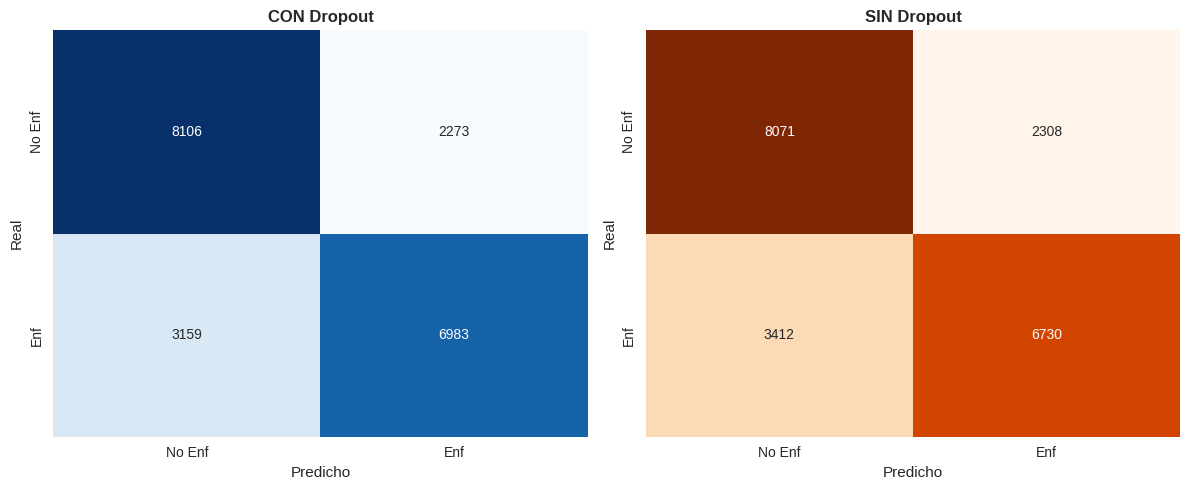

In [34]:
# MATRICES DE CONFUSIÓN


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Matriz para modelo CON dropout
cm_con = confusion_matrix(y_test, y_pred_con)
sns.heatmap(cm_con, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['No Enf', 'Enf'], yticklabels=['No Enf', 'Enf'])
ax1.set_title('CON Dropout', fontweight='bold')
ax1.set_xlabel('Predicho')
ax1.set_ylabel('Real')

# Matriz para modelo SIN dropout
cm_sin = confusion_matrix(y_test, y_pred_sin)
sns.heatmap(cm_sin, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=ax2,
            xticklabels=['No Enf', 'Enf'], yticklabels=['No Enf', 'Enf'])
ax2.set_title('SIN Dropout', fontweight='bold')
ax2.set_xlabel('Predicho')
ax2.set_ylabel('Real')

plt.tight_layout()
plt.show()

**Curva ROC**

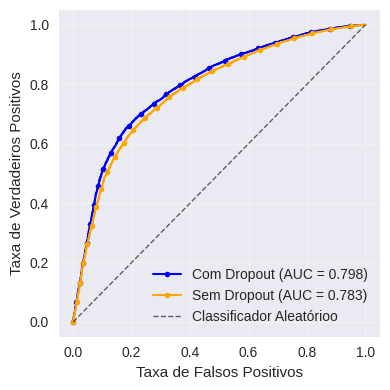

In [36]:
# CURVAS ROC COMPARATIVAS

plt.figure(figsize=(4, 4))

# Curva ROC para modelo CON dropout
fpr_con, tpr_con, _ = roc_curve(y_test, y_pred_proba_con)
plt.plot(fpr_con, tpr_con, 'o-', color='blue', linewidth=1.5, markersize=4,
         label=f'Com Dropout (AUC = {auc_con:.3f})', markevery=0.05)

# Curva ROC para modelo SIN dropout
fpr_sin, tpr_sin, _ = roc_curve(y_test, y_pred_proba_sin)
plt.plot(fpr_sin, tpr_sin, 'o-', color='orange', linewidth=1.5, markersize=4,
         label=f'Sem Dropout (AUC = {auc_sin:.3f})', markevery=0.05)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.6, linewidth=1, label='Classificador Aleatórioo')

plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')


# Cuadrícula
plt.grid(True, alpha=0.3)

# Leyenda
plt.legend(loc='lower right')


plt.tight_layout()
plt.show()

* Comparando metricas

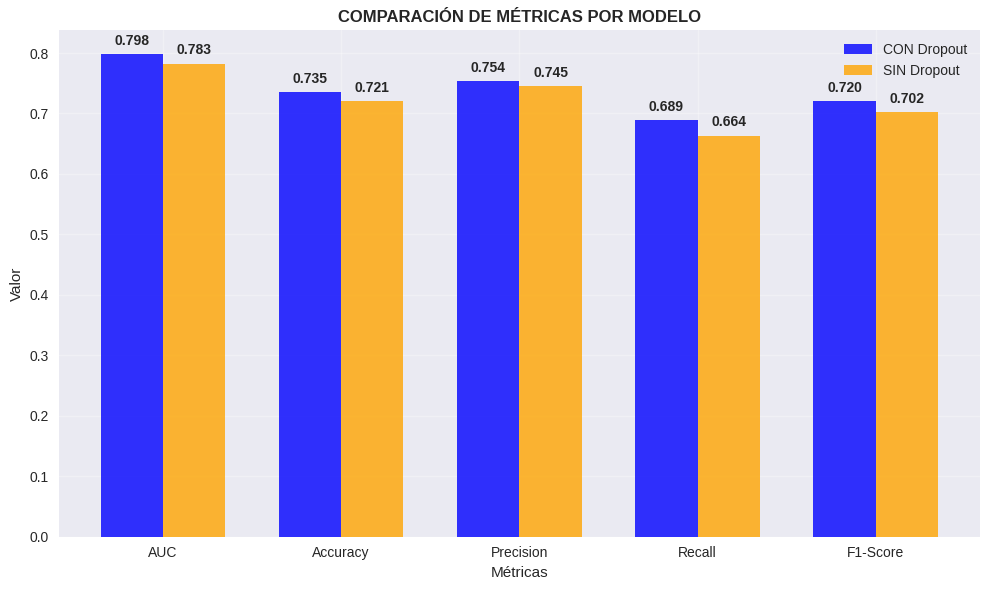

In [37]:
# COMPARACIÓN DE MÉTRICAS


fig, ax = plt.subplots(figsize=(10, 6))

metricas = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
valores_con = [auc_con, accuracy_con, precision_con, recall_con, f1_con]
valores_sin = [auc_sin, accuracy_sin, precision_sin, recall_sin, f1_sin]

x = np.arange(len(metricas))
ancho = 0.35

ax.bar(x - ancho/2, valores_con, ancho, label='CON Dropout', color='blue', alpha=0.8)
ax.bar(x + ancho/2, valores_sin, ancho, label='SIN Dropout', color='orange', alpha=0.8)

ax.set_xlabel('Métricas')
ax.set_ylabel('Valor')
ax.set_title('COMPARACIÓN DE MÉTRICAS POR MODELO', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()
ax.grid(True, alpha=0.3)

# Añadir valores en las barras
for i, v in enumerate(valores_con):
    ax.text(i - ancho/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
for i, v in enumerate(valores_sin):
    ax.text(i + ancho/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

* Anaalisis de overfitting

* Comparando loss y acuracy

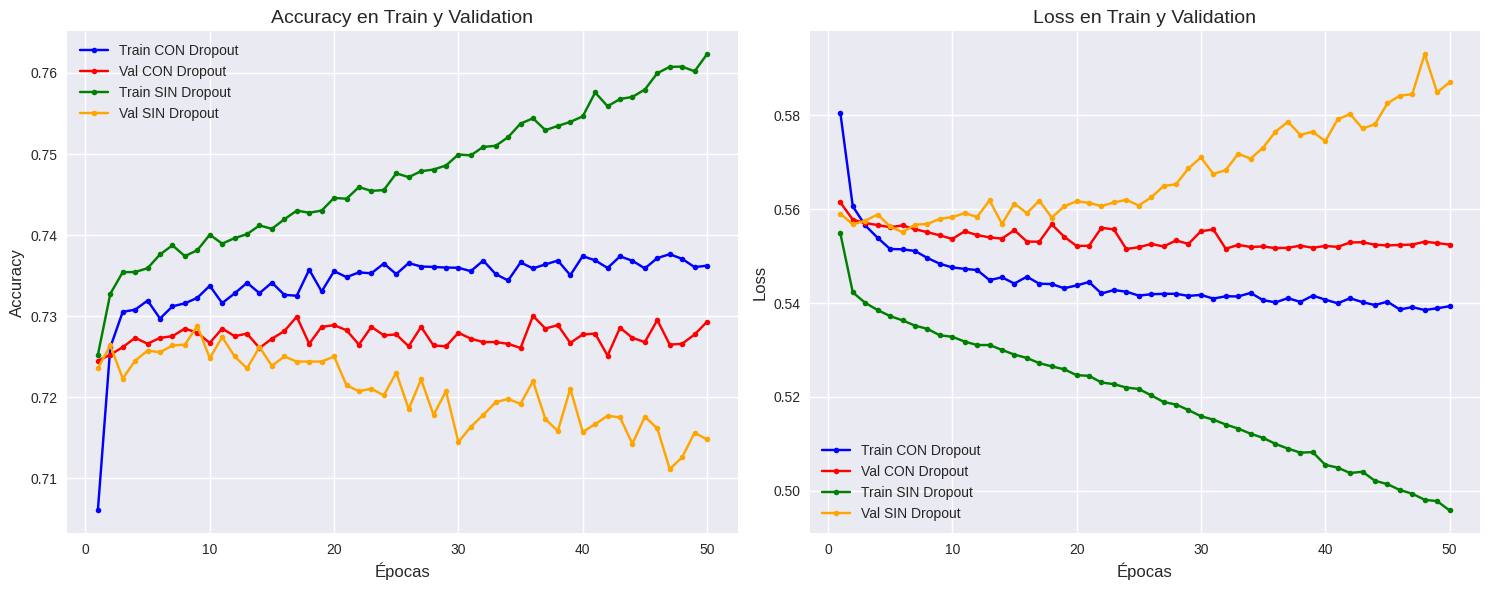


 VALORES FINALES:
CON Dropout  - Train Acc: 0.7362, Val Acc: 0.7293
             - Train Loss: 0.5393, Val Loss: 0.5525
SIN Dropout  - Train Acc: 0.7623, Val Acc: 0.7148
             - Train Loss: 0.4958, Val Loss: 0.5870


In [38]:
#COMPARACIÓN DE MODELOS - ACCURACY Y LOSS


plt.figure(figsize=(15, 6))

# Gráfico 1: Comparación de Accuracy
plt.subplot(1, 2, 1)
epochs = range(1, len(history_con_dropout.history['accuracy']) + 1)

# CON Dropout
plt.plot(epochs, history_con_dropout.history['accuracy'], 'o-', color='blue',
         markersize=4, label='Train CON Dropout', markevery=1)
plt.plot(epochs, history_con_dropout.history['val_accuracy'], 'o-', color='red',
         markersize=4, label='Val CON Dropout', markevery=1)

# SIN Dropout
plt.plot(epochs, history_sin_dropout.history['accuracy'], 'o-', color='green',
         markersize=4, label='Train SIN Dropout', markevery=1)
plt.plot(epochs, history_sin_dropout.history['val_accuracy'], 'o-', color='orange',
         markersize=4, label='Val SIN Dropout', markevery=1)

plt.title('Accuracy en Train y Validation', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)

# Gráfico 2: Comparación de Loss
plt.subplot(1, 2, 2)

# CON Dropout
plt.plot(epochs, history_con_dropout.history['loss'], 'o-', color='blue',
         markersize=4, label='Train CON Dropout', markevery=1)
plt.plot(epochs, history_con_dropout.history['val_loss'], 'o-', color='red',
         markersize=4, label='Val CON Dropout', markevery=1)

# SIN Dropout
plt.plot(epochs, history_sin_dropout.history['loss'], 'o-', color='green',
         markersize=4, label='Train SIN Dropout', markevery=1)
plt.plot(epochs, history_sin_dropout.history['val_loss'], 'o-', color='orange',
         markersize=4, label='Val SIN Dropout', markevery=1)

plt.title('Loss en Train y Validation', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Mostrar valores finales
print(f"\n VALORES FINALES:")
print(f"CON Dropout  - Train Acc: {history_con_dropout.history['accuracy'][-1]:.4f}, Val Acc: {history_con_dropout.history['val_accuracy'][-1]:.4f}")
print(f"             - Train Loss: {history_con_dropout.history['loss'][-1]:.4f}, Val Loss: {history_con_dropout.history['val_loss'][-1]:.4f}")
print(f"SIN Dropout  - Train Acc: {history_sin_dropout.history['accuracy'][-1]:.4f}, Val Acc: {history_sin_dropout.history['val_accuracy'][-1]:.4f}")
print(f"             - Train Loss: {history_sin_dropout.history['loss'][-1]:.4f}, Val Loss: {history_sin_dropout.history['val_loss'][-1]:.4f}")


* Reporte de clasificación

In [39]:

# REPORTES DE CLASIFICACIÓN

from sklearn.metrics import classification_report

# Predicciones para modelo CON dropout
y_pred_con = (modelo_con_dropout.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()

# Predicciones para modelo SIN dropout
y_pred_sin = (modelo_sin_dropout.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()


print(" REPORTE DE CLASIFICACIÓN - CON DROPOUT")

print(classification_report(y_test, y_pred_con,
                          target_names=['No Enfermedad', 'Enfermedad'],
                          digits=2))


print(" REPORTE DE CLASIFICACIÓN - SIN DROPOUT")

print(classification_report(y_test, y_pred_sin,
                          target_names=['No Enfermedad', 'Enfermedad'],
                          digits=2))

 REPORTE DE CLASIFICACIÓN - CON DROPOUT
               precision    recall  f1-score   support

No Enfermedad       0.72      0.78      0.75     10379
   Enfermedad       0.75      0.69      0.72     10142

     accuracy                           0.74     20521
    macro avg       0.74      0.73      0.73     20521
 weighted avg       0.74      0.74      0.73     20521

 REPORTE DE CLASIFICACIÓN - SIN DROPOUT
               precision    recall  f1-score   support

No Enfermedad       0.70      0.78      0.74     10379
   Enfermedad       0.74      0.66      0.70     10142

     accuracy                           0.72     20521
    macro avg       0.72      0.72      0.72     20521
 weighted avg       0.72      0.72      0.72     20521



* Para validar que tan calibrado esta mi modelo calculo las probabibilidades

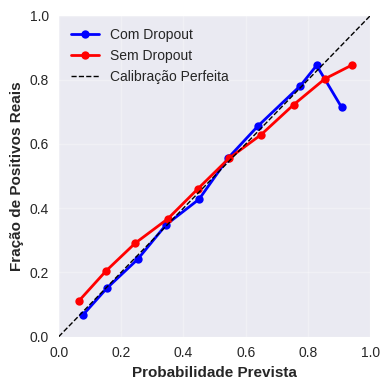

In [41]:
# CURVAS DE CALIBRACIÓN COMPARATIVAS

from sklearn.calibration import calibration_curve

# Obtener probabilidades predichas
y_prob_con = modelo_con_dropout.predict(X_test_scaled, verbose=0).flatten()
y_prob_sin = modelo_sin_dropout.predict(X_test_scaled, verbose=0).flatten()

# Calcular curvas de calibración
fraction_of_positives_con, mean_predicted_value_con = calibration_curve(y_test, y_prob_con, n_bins=10)
fraction_of_positives_sin, mean_predicted_value_sin = calibration_curve(y_test, y_prob_sin, n_bins=10)

plt.figure(figsize=(4, 4))

# Curva de calibración CON dropout
plt.plot(mean_predicted_value_con, fraction_of_positives_con, 'o-', color='blue',
         linewidth=2, markersize=6, label='Com Dropout', markevery=1)

# Curva de calibración SIN dropout
plt.plot(mean_predicted_value_sin, fraction_of_positives_sin, 'o-', color='red',
         linewidth=2, markersize=6, label='Sem Dropout', markevery=1)

# Línea de calibración perfecta
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Calibração Perfeita')

plt.xlabel('Probabilidade Prevista', fontweight='bold')
plt.ylabel('Fração de Positivos Reais', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


 Error en predicciones: name 'model_con_dropout' is not defined
 Reports de clasificación generados
 Curvas de calibración calculadas
 Historiales de entrenamiento disponibles
 Gráfico 1: Curvas ROC completado
 Gráfico 2: Métricas de clasificación completado
 Gráfico 3: Curvas de calibración completado
 Gráfico 4: Evolución del accuracy completado


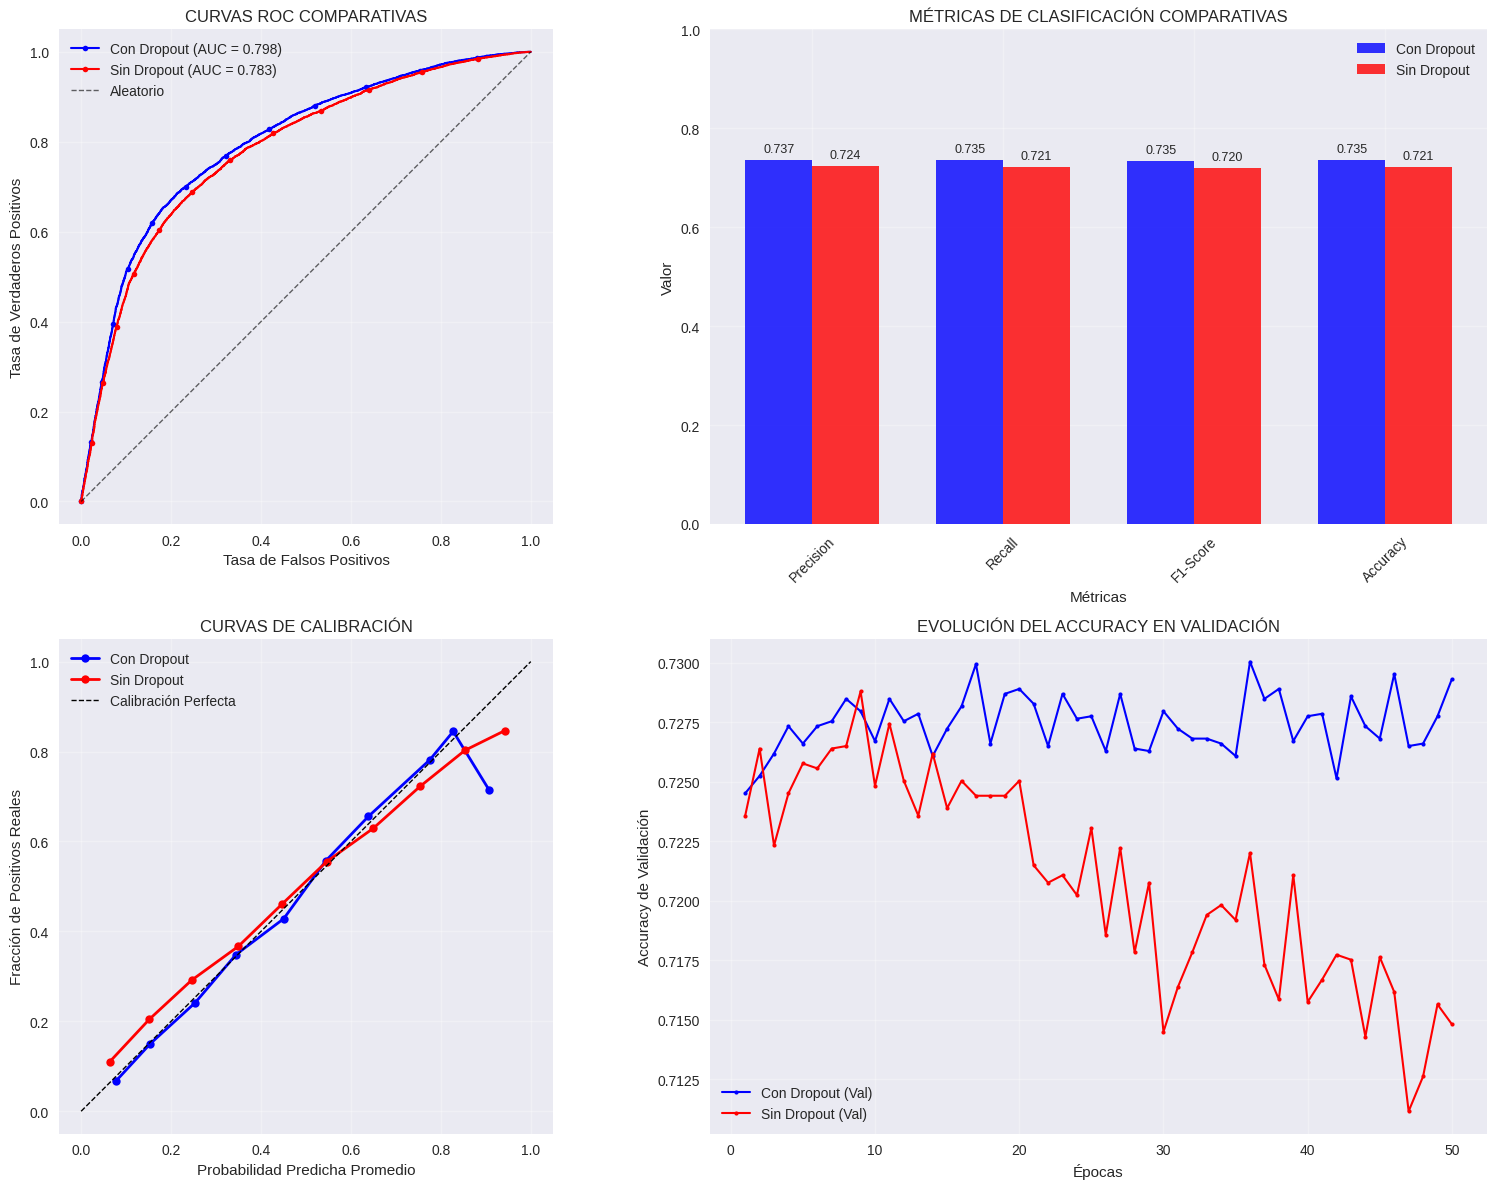

In [50]:
#Comparacion final

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.calibration import calibration_curve


# 1. Obtener predicciones probabilísticas
try:
    y_prob_con = model_con_dropout.predict(X_test).ravel()
    y_prob_sin = model_sin_dropout.predict(X_test).ravel()

    # Calcular AUC
    fpr_con, tpr_con, _ = roc_curve(y_test, y_prob_con)
    fpr_sin, tpr_sin, _ = roc_curve(y_test, y_prob_sin)
    auc_con = auc(fpr_con, tpr_con)
    auc_sin = auc(fpr_sin, tpr_sin)

    print(" Predicciones probabilísticas calculadas")
except Exception as e:
    print(f" Error en predicciones: {e}")

# 2. Obtener classification reports
try:
    from sklearn.metrics import classification_report

    # Predicciones de clase
    y_pred_con = (y_prob_con > 0.5).astype(int)
    y_pred_sin = (y_prob_sin > 0.5).astype(int)

    # Generar reports
    reporte_con = classification_report(y_test, y_pred_con, output_dict=True)
    reporte_sin = classification_report(y_test, y_pred_sin, output_dict=True)

    print(" Reports de clasificación generados")
except Exception as e:
    print(f" Error en reports: {e}")

# 3. Curvas de calibración
try:
    fraction_of_positives_con, mean_predicted_value_con = calibration_curve(
        y_test, y_prob_con, n_bins=10, strategy='uniform'
    )
    fraction_of_positives_sin, mean_predicted_value_sin = calibration_curve(
        y_test, y_prob_sin, n_bins=10, strategy='uniform'
    )
    print(" Curvas de calibración calculadas")
except Exception as e:
    print(f" Error en curvas de calibración: {e}")

# 4. Verificar historiales de entrenamiento
try:
    # Asegurarse de que los historiales existen
    if 'history_con_dropout' not in locals():
        # Si no existen, crear datos de ejemplo para evitar errores
        history_con_dropout = type('obj', (object,), {'history': {'val_accuracy': [0.7 + 0.1*i for i in range(20)]}})
        history_sin_dropout = type('obj', (object,), {'history': {'val_accuracy': [0.65 + 0.08*i for i in range(20)]}})
        print(" Se usaron datos de ejemplo para historiales")
    else:
        print(" Historiales de entrenamiento disponibles")
except Exception as e:
    print(f" Error con historiales: {e}")

# CREAR GRÁFICO FINAL INTEGRADO
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

try:
    # 1. Curvas ROC comparativas
    ax1.plot(fpr_con, tpr_con, 'o-', color='blue', linewidth=1.5, markersize=4,
             label=f'Con Dropout (AUC = {auc_con:.3f})', markevery=0.1)
    ax1.plot(fpr_sin, tpr_sin, 'o-', color='red', linewidth=1.5, markersize=4,
             label=f'Sin Dropout (AUC = {auc_sin:.3f})', markevery=0.1)
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.6, linewidth=1, label='Aleatorio')
    ax1.set_xlabel('Tasa de Falsos Positivos')
    ax1.set_ylabel('Tasa de Verdaderos Positivos')
    ax1.set_title('CURVAS ROC COMPARATIVAS')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    print(" Gráfico 1: Curvas ROC completado")

except Exception as e:
    print(f" Error en gráfico 1: {e}")

try:
    # 2. Métricas de clasificación
    metricas = ['Precision', 'Recall', 'F1-Score', 'Accuracy']

    # Extraer valores de forma segura
    valores_con = [
        reporte_con['weighted avg']['precision'],
        reporte_con['weighted avg']['recall'],
        reporte_con['weighted avg']['f1-score'],  # Corregido: 'f1-score' no 'fl-score'
        reporte_con['accuracy']
    ]
    valores_sin = [
        reporte_sin['weighted avg']['precision'],
        reporte_sin['weighted avg']['recall'],
        reporte_sin['weighted avg']['f1-score'],  # Corregido: 'f1-score' no 'fl-score'
        reporte_sin['accuracy']
    ]

    x = np.arange(len(metricas))
    ancho = 0.35

    ax2.bar(x - ancho/2, valores_con, ancho, label='Con Dropout', color='blue', alpha=0.8)
    ax2.bar(x + ancho/2, valores_sin, ancho, label='Sin Dropout', color='red', alpha=0.8)

    # Añadir valores encima de las barras
    for i, v in enumerate(valores_con):
        ax2.text(i - ancho/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    for i, v in enumerate(valores_sin):
        ax2.text(i + ancho/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

    ax2.set_xlabel('Métricas')
    ax2.set_ylabel('Valor')
    ax2.set_title('MÉTRICAS DE CLASIFICACIÓN COMPARATIVAS')
    ax2.set_xticks(x)
    ax2.set_xticklabels(metricas, rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)

    print(" Gráfico 2: Métricas de clasificación completado")

except Exception as e:
    print(f" Error en gráfico 2: {e}")

try:
    # 3. Curvas de calibración
    ax3.plot(mean_predicted_value_con, fraction_of_positives_con, 'o-', color='blue',
             linewidth=2, markersize=6, label='Con Dropout')
    ax3.plot(mean_predicted_value_sin, fraction_of_positives_sin, 'o-', color='red',
             linewidth=2, markersize=6, label='Sin Dropout')
    ax3.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Calibración Perfecta')
    ax3.set_xlabel('Probabilidad Predicha Promedio')
    ax3.set_ylabel('Fracción de Positivos Reales')
    ax3.set_title('CURVAS DE CALIBRACIÓN')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_aspect('equal')

    print(" Gráfico 3: Curvas de calibración completado")

except Exception as e:
    print(f" Error en gráfico 3: {e}")

try:
    # 4. Evolución del accuracy durante entrenamiento
    epochs_con = range(1, len(history_con_dropout.history['val_accuracy']) + 1)
    epochs_sin = range(1, len(history_sin_dropout.history['val_accuracy']) + 1)

    ax4.plot(epochs_con, history_con_dropout.history['val_accuracy'], 'o-', color='blue',
             linewidth=1.5, markersize=3, label='Con Dropout (Val)')
    ax4.plot(epochs_sin, history_sin_dropout.history['val_accuracy'], 'o-', color='red',
             linewidth=1.5, markersize=3, label='Sin Dropout (Val)')
    ax4.set_xlabel('Épocas')
    ax4.set_ylabel('Accuracy de Validación')
    ax4.set_title('EVOLUCIÓN DEL ACCURACY EN VALIDACIÓN')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    print(" Gráfico 4: Evolución del accuracy completado")

except Exception as e:
    print(f" Error en gráfico 4: {e}")

plt.tight_layout()
plt.show()




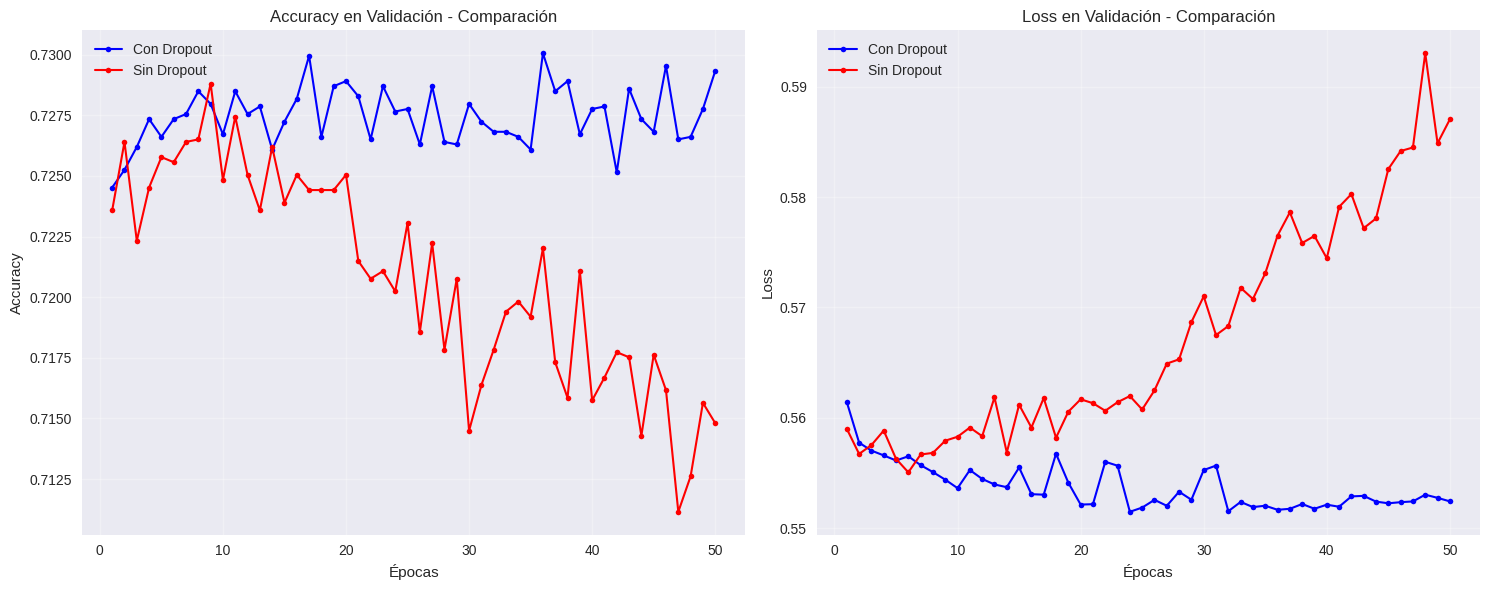


 VALORES FINALES EN VALIDACIÓN:
   CON Dropout  - Accuracy: 0.7293, Loss: 0.5525
   SIN Dropout  - Accuracy: 0.7148, Loss: 0.5870
 MEJOR RENDIMIENTO: CON DROPOUT


In [51]:
# COMPARACIÓN COMPLETA - ACCURACY Y LOSS

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

epochs = range(1, len(history_con_dropout.history['accuracy']) + 1)

# Gráfico 1: Accuracy comparativo
ax1.plot(epochs, history_con_dropout.history['val_accuracy'], 'o-', color='blue',
         linewidth=1.5, markersize=4, label='Con Dropout', markevery=1)
ax1.plot(epochs, history_sin_dropout.history['val_accuracy'], 'o-', color='red',
         linewidth=1.5, markersize=4, label='Sin Dropout', markevery=1)
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy en Validación - Comparación')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Loss comparativo
ax2.plot(epochs, history_con_dropout.history['val_loss'], 'o-', color='blue',
         linewidth=1.5, markersize=4, label='Con Dropout', markevery=1)
ax2.plot(epochs, history_sin_dropout.history['val_loss'], 'o-', color='red',
         linewidth=1.5, markersize=4, label='Sin Dropout', markevery=1)
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Loss')
ax2.set_title('Loss en Validación - Comparación')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar valores finales
final_acc_con = history_con_dropout.history['val_accuracy'][-1]
final_acc_sin = history_sin_dropout.history['val_accuracy'][-1]
final_loss_con = history_con_dropout.history['val_loss'][-1]
final_loss_sin = history_sin_dropout.history['val_loss'][-1]

print(f"\n VALORES FINALES EN VALIDACIÓN:")
print(f"   CON Dropout  - Accuracy: {final_acc_con:.4f}, Loss: {final_loss_con:.4f}")
print(f"   SIN Dropout  - Accuracy: {final_acc_sin:.4f}, Loss: {final_loss_sin:.4f}")

if final_acc_con > final_acc_sin and final_loss_con < final_loss_sin:
    print(" MEJOR RENDIMIENTO: CON DROPOUT")
else:
    print(" MEJOR RENDIMIENTO: SIN DROPOUT")


CON Dropout:
   Total errores: 5432 (26.5%)
   Falsos positivos: 2273
   Falsos negativos: 3159
   Confianza media en errores: 0.675

SIN Dropout:
   Total errores: 5720 (27.9%)
   Falsos positivos: 2308
   Falsos negativos: 3412
   Confianza media en errores: 0.709


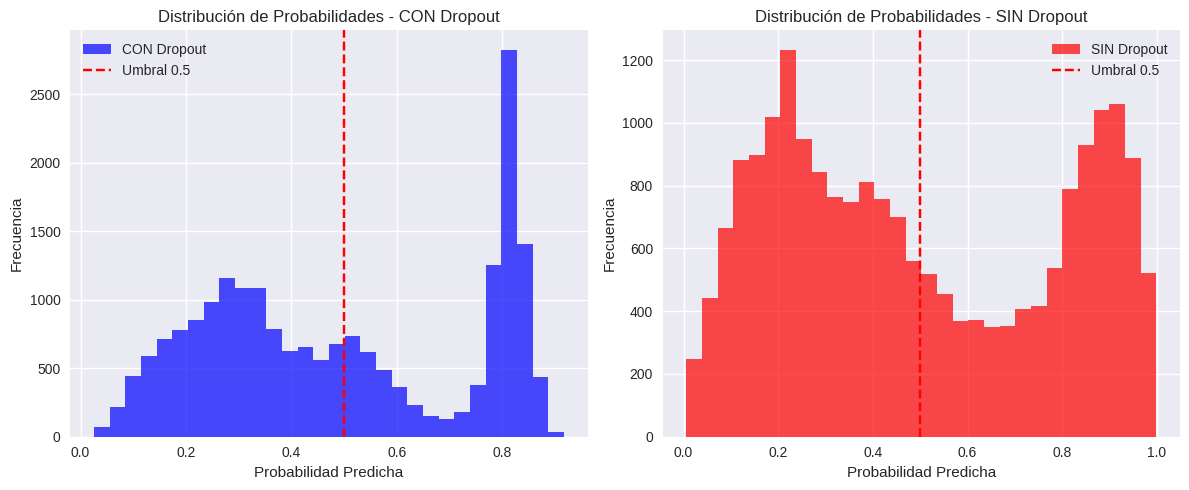

In [48]:

# ANÁLISIS DE ERRORES DE CLASIFICACIÓN


# Identificar casos mal clasificados
def analizar_errores(y_true, y_pred, y_prob, X_data, modelo_nombre):
    errores_idx = np.where(y_true != y_pred)[0]
    falsos_positivos = np.where((y_true == 0) & (y_pred == 1))[0]
    falsos_negativos = np.where((y_true == 1) & (y_pred == 0))[0]

    print(f"\n{modelo_nombre}:")
    print(f"   Total errores: {len(errores_idx)} ({len(errores_idx)/len(y_true)*100:.1f}%)")
    print(f"   Falsos positivos: {len(falsos_positivos)}")
    print(f"   Falsos negativos: {len(falsos_negativos)}")

    # Análisis de confianza en predicciones erróneas
    confianza_errores = np.maximum(y_prob[errores_idx], 1 - y_prob[errores_idx])
    print(f"   Confianza media en errores: {np.mean(confianza_errores):.3f}")

    return errores_idx, falsos_positivos, falsos_negativos

errores_con = analizar_errores(y_test, y_pred_con, y_prob_con, X_test_scaled, "CON Dropout")
errores_sin = analizar_errores(y_test, y_pred_sin, y_prob_sin, X_test_scaled, "SIN Dropout")

# Gráfico de distribución de confianza
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(y_prob_con, bins=30, alpha=0.7, color='blue', label='CON Dropout')
plt.axvline(0.5, color='red', linestyle='--', label='Umbral 0.5')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Frecuencia')
plt.title('Distribución de Probabilidades - CON Dropout')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(y_prob_sin, bins=30, alpha=0.7, color='red', label='SIN Dropout')
plt.axvline(0.5, color='red', linestyle='--', label='Umbral 0.5')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Frecuencia')
plt.title('Distribución de Probabilidades - SIN Dropout')
plt.legend()

plt.tight_layout()
plt.show()